# EDA

In [1]:
import pandas as pd
import numpy as np
from typing import Tuple
from matplotlib import pyplot as plt

raw = pd.read_csv("ecuador_training_data.csv")
raw_big = pd.read_csv("data_merged.csv")

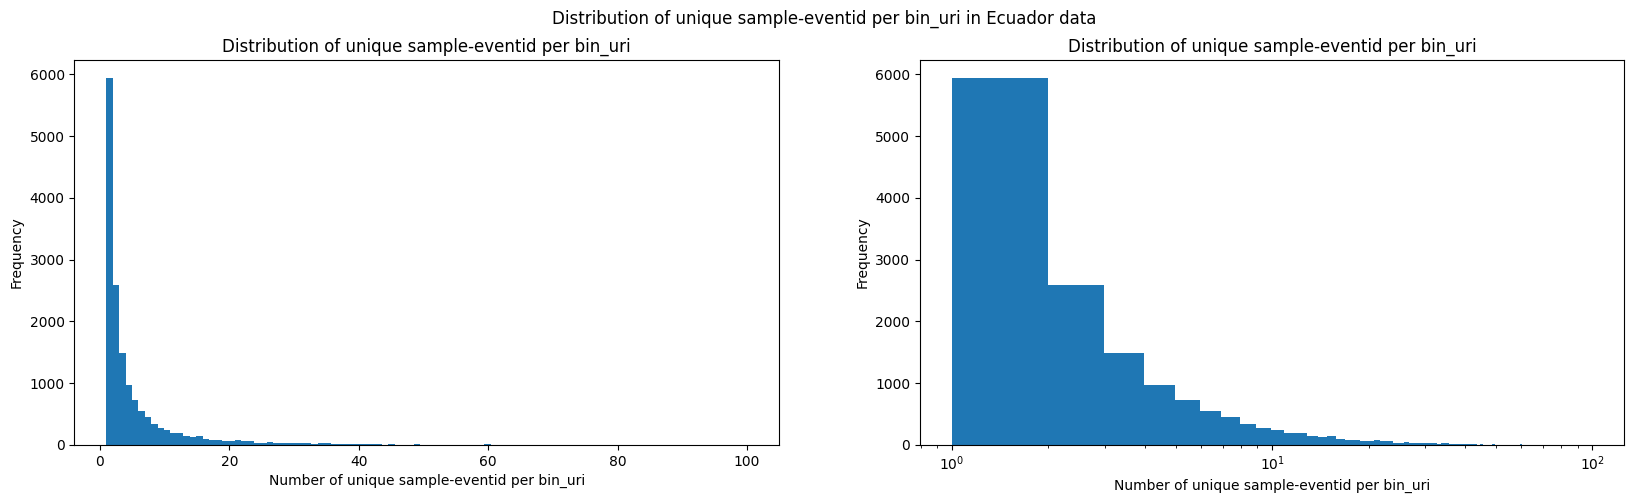

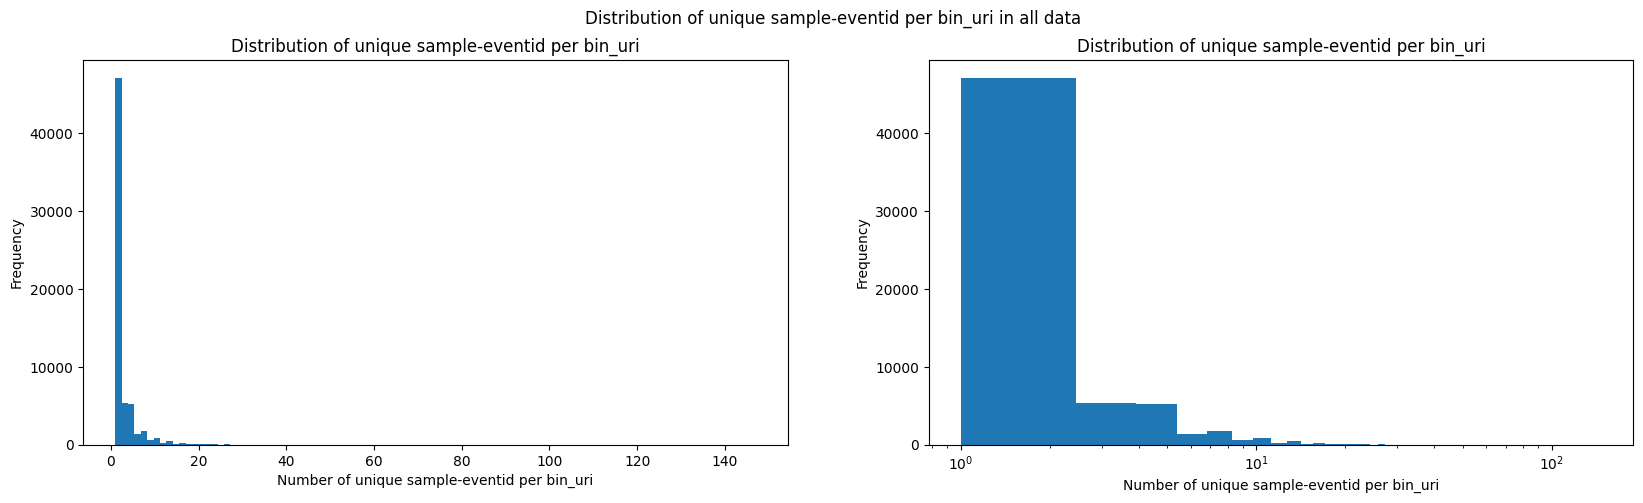

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
raw.groupby("bin_uri")['sample-eventid'].nunique().plot(kind='hist', bins=100, ax=axes[0])
axes[0].set_xlabel("Number of unique sample-eventid per bin_uri")
axes[0].set_title("Distribution of unique sample-eventid per bin_uri")

#raw.groupby("bin_uri")['sample-eventid'].nunique().plot(kind='hist', bins=100, ax=axes[1], log=True)
#axes[1].set_xlabel("Number of unique sample-eventid per bin_uri")
#axes[1].set_title("Distribution of unique sample-eventid per bin_uri")
#axes[1].set_yscale('log')

raw.groupby("bin_uri")['sample-eventid'].nunique().plot(kind='hist', bins=100, ax=axes[1], log=False)
axes[1].set_xlabel("Number of unique sample-eventid per bin_uri")
axes[1].set_title("Distribution of unique sample-eventid per bin_uri")
axes[1].set_xscale('log')

fig.suptitle("Distribution of unique sample-eventid per bin_uri in Ecuador data")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
raw_big.groupby("bin_uri")['sample-eventid'].nunique().plot(kind='hist', bins=100, ax=axes[0])
axes[0].set_xlabel("Number of unique sample-eventid per bin_uri")
axes[0].set_title("Distribution of unique sample-eventid per bin_uri")

#raw_big.groupby("bin_uri")['sample-eventid'].nunique().plot(kind='hist', bins=100, ax=axes[1], log=True)
#axes[1].set_xlabel("Number of unique sample-eventid per bin_uri")
#axes[1].set_title("Distribution of unique sample-eventid per bin_uri")
#axes[1].set_yscale('log')

raw_big.groupby("bin_uri")['sample-eventid'].nunique().plot(kind='hist', bins=100, ax=axes[1], log=False)
axes[1].set_xlabel("Number of unique sample-eventid per bin_uri")
axes[1].set_title("Distribution of unique sample-eventid per bin_uri")
axes[1].set_xscale('log')

fig.suptitle("Distribution of unique sample-eventid per bin_uri in all data")
plt.show()


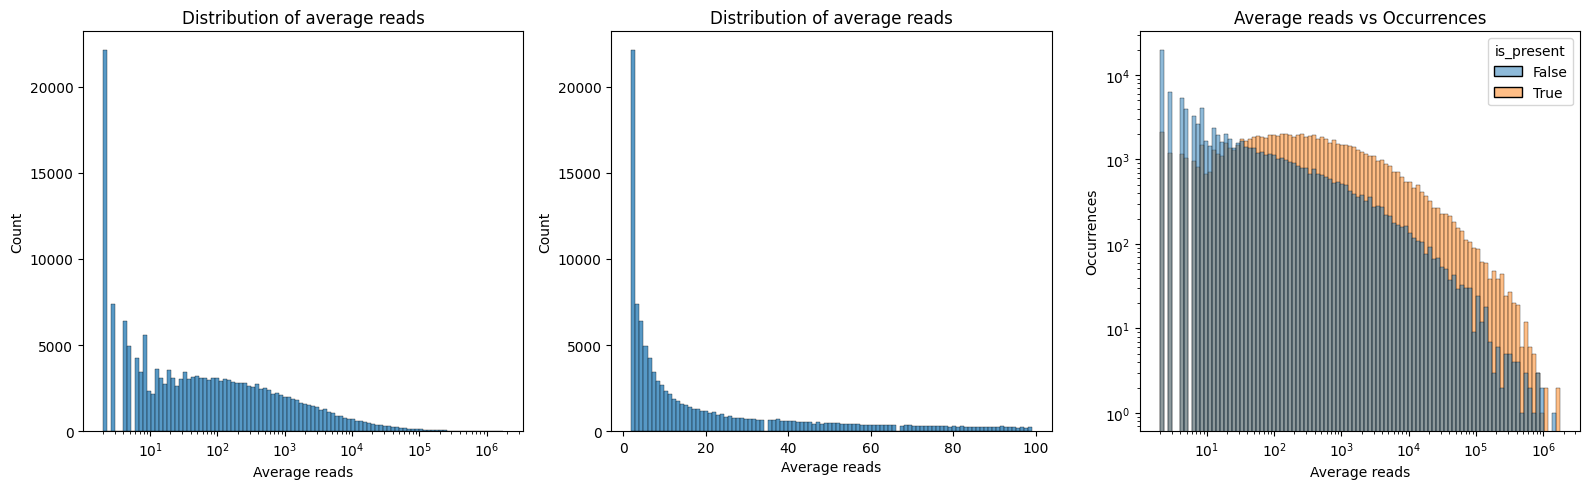

In [3]:
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.histplot(raw_big, x='total_reads', bins=100, log_scale=(True, False), ax=axes[0])
axes[0].set_xlabel("Average reads")
axes[0].set_title("Distribution of average reads")

sns.histplot(raw_big[raw_big['total_reads'] < 100], x='total_reads', bins=100, log_scale=(False, False), ax=axes[1])
axes[1].set_xlabel("Average reads")
axes[1].set_title("Distribution of average reads")
#axes[1].set_xscale('log')
#axes[1].set_yscale('log')

raw_big['is_present'] = raw_big['occurrences'] > 0
sns.histplot(data=raw_big, x='total_reads', hue='is_present', bins=100, log_scale=(True, True), ax=axes[2], multiple='layer', stat='count')
axes[2].set_xlabel("Average reads")
axes[2].set_ylabel("Occurrences")
#axes[2].set_xscale('log')
axes[2].set_yscale('log')
axes[2].set_title("Average reads vs Occurrences")
plt.tight_layout()
plt.show()



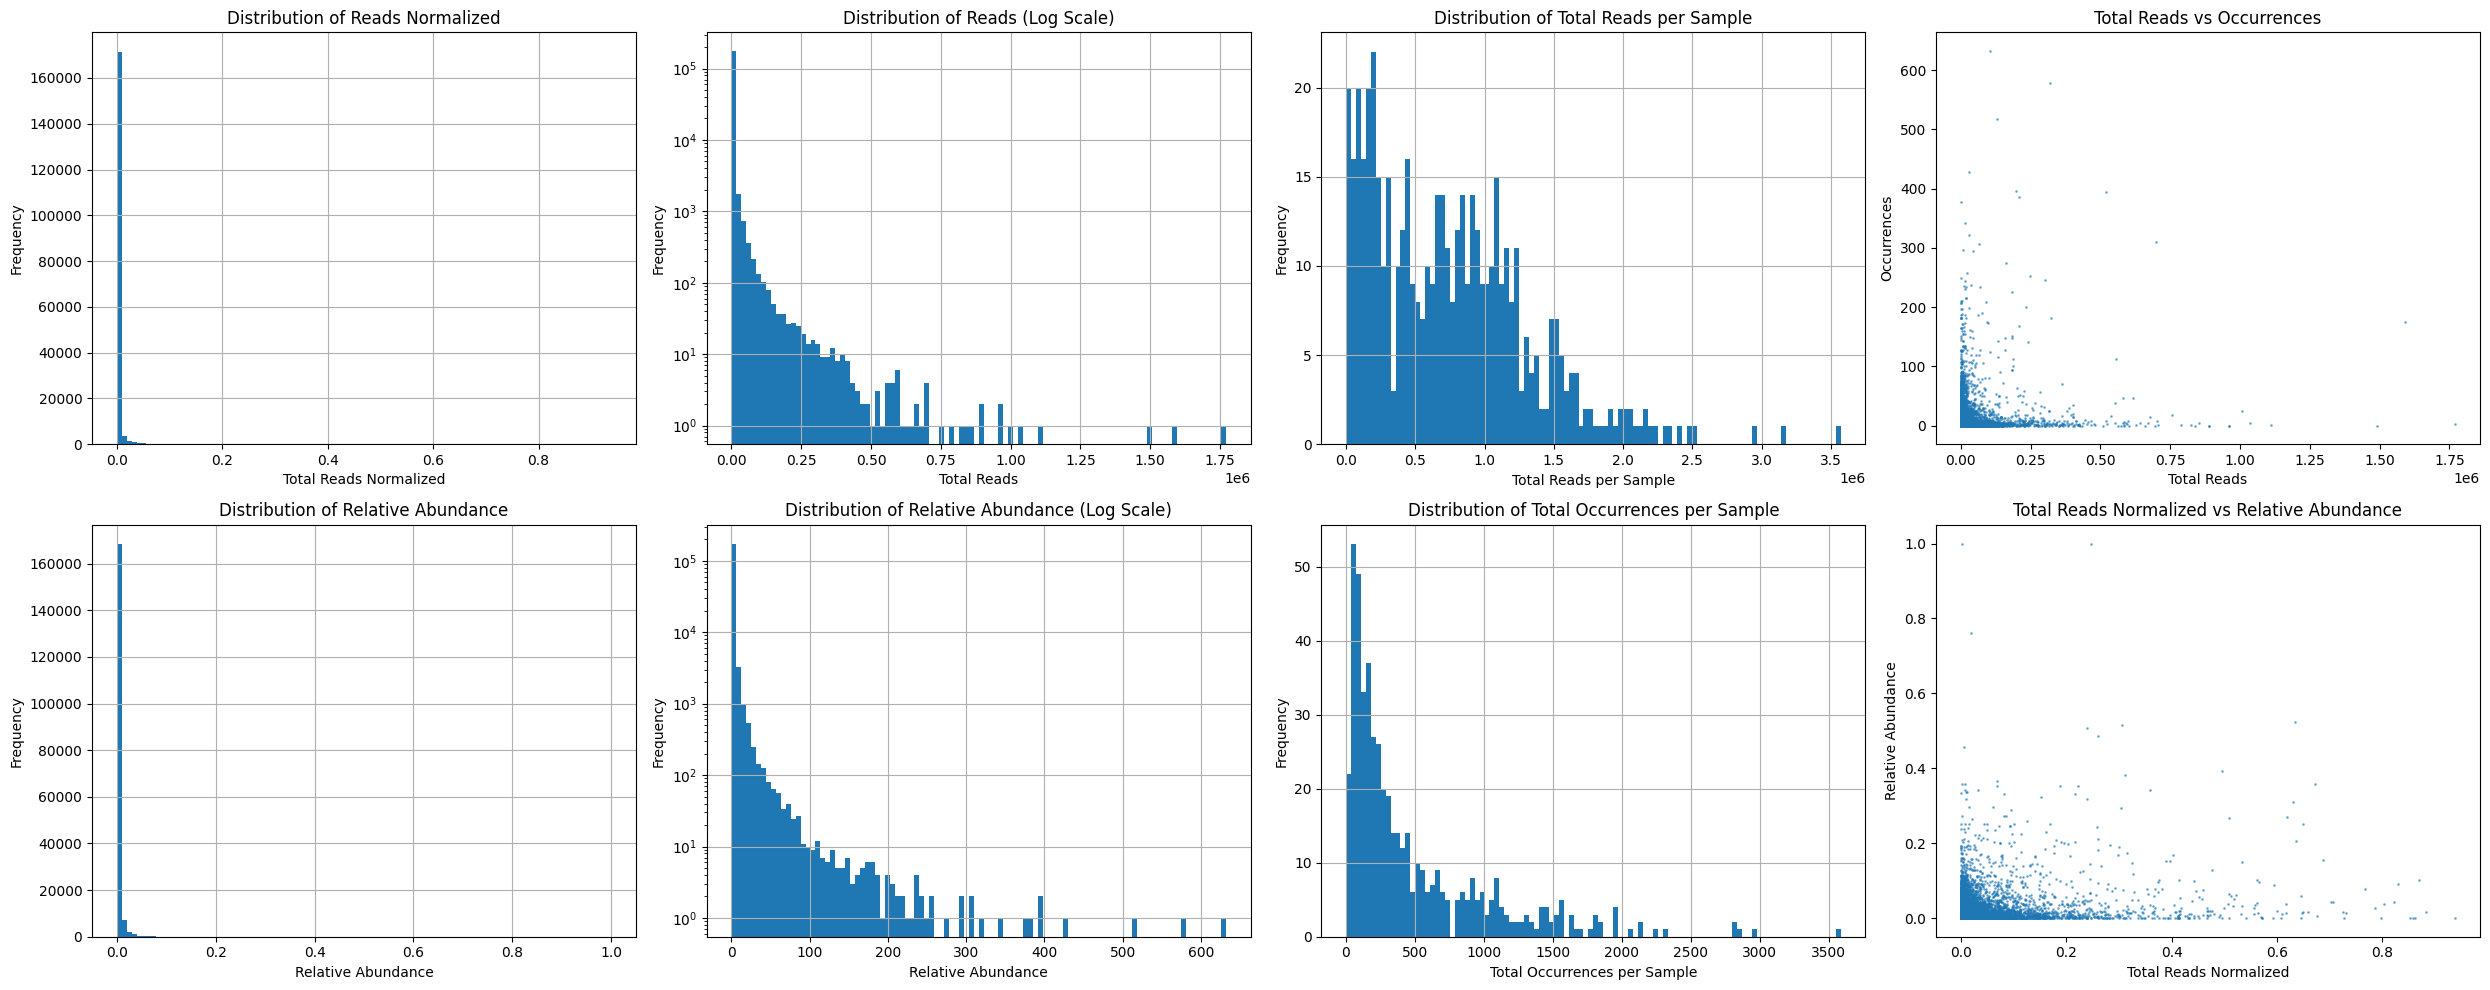

In [4]:
from regex import R


fig, axes = plt.subplots(2, 4, figsize=(25, 10))
raw_big['total_reads_norm'] = raw_big['total_reads'] / raw_big.groupby('sample-eventid')['total_reads'].transform('sum')
raw_big.total_reads_norm.hist(bins=100, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Reads Normalized')
axes[0, 0].set_xlabel('Total Reads Normalized')
axes[0, 0].set_ylabel('Frequency')
raw_big.total_reads.hist(bins=100, log=True, ax=axes[0, 1])
axes[0, 1].set_title('Distribution of Reads (Log Scale)')
axes[0, 1].set_xlabel('Total Reads')
axes[0, 1].set_ylabel('Frequency')
raw_big.groupby("sample-eventid").total_reads.sum().hist(bins=100, ax=axes[0, 2])
axes[0, 2].set_title('Distribution of Total Reads per Sample')
axes[0, 2].set_xlabel('Total Reads per Sample')
axes[0, 2].set_ylabel('Frequency')
axes[0, 3].scatter(raw_big['total_reads'], raw_big['occurrences'], s=1, alpha=0.5)
axes[0, 3].set_title('Total Reads vs Occurrences')
axes[0, 3].set_xlabel('Total Reads')
axes[0, 3].set_ylabel('Occurrences')

raw_big["relative_abundance"] = raw_big['occurrences'] / raw_big.groupby('sample-eventid')['occurrences'].transform('sum')
raw_big.relative_abundance.hist(bins=100, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Relative Abundance')
axes[1, 0].set_xlabel('Relative Abundance')
axes[1, 0].set_ylabel('Frequency')
raw_big.occurrences.hist(bins=100, log=True, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Relative Abundance (Log Scale)')
axes[1, 1].set_xlabel('Relative Abundance')
axes[1, 1].set_ylabel('Frequency')
raw_big.groupby("sample-eventid").occurrences.sum().hist(bins=100, ax=axes[1, 2])
axes[1, 2].set_title('Distribution of Total Occurrences per Sample')
axes[1, 2].set_xlabel('Total Occurrences per Sample')
axes[1, 2].set_ylabel('Frequency')
axes[1, 3].scatter(raw_big['total_reads_norm'], raw_big['relative_abundance'], s=1, alpha=0.5)
axes[1, 3].set_title('Total Reads Normalized vs Relative Abundance')
axes[1, 3].set_xlabel('Total Reads Normalized')
axes[1, 3].set_ylabel('Relative Abundance')
plt.tight_layout()
plt.show()

# Outliers Detection

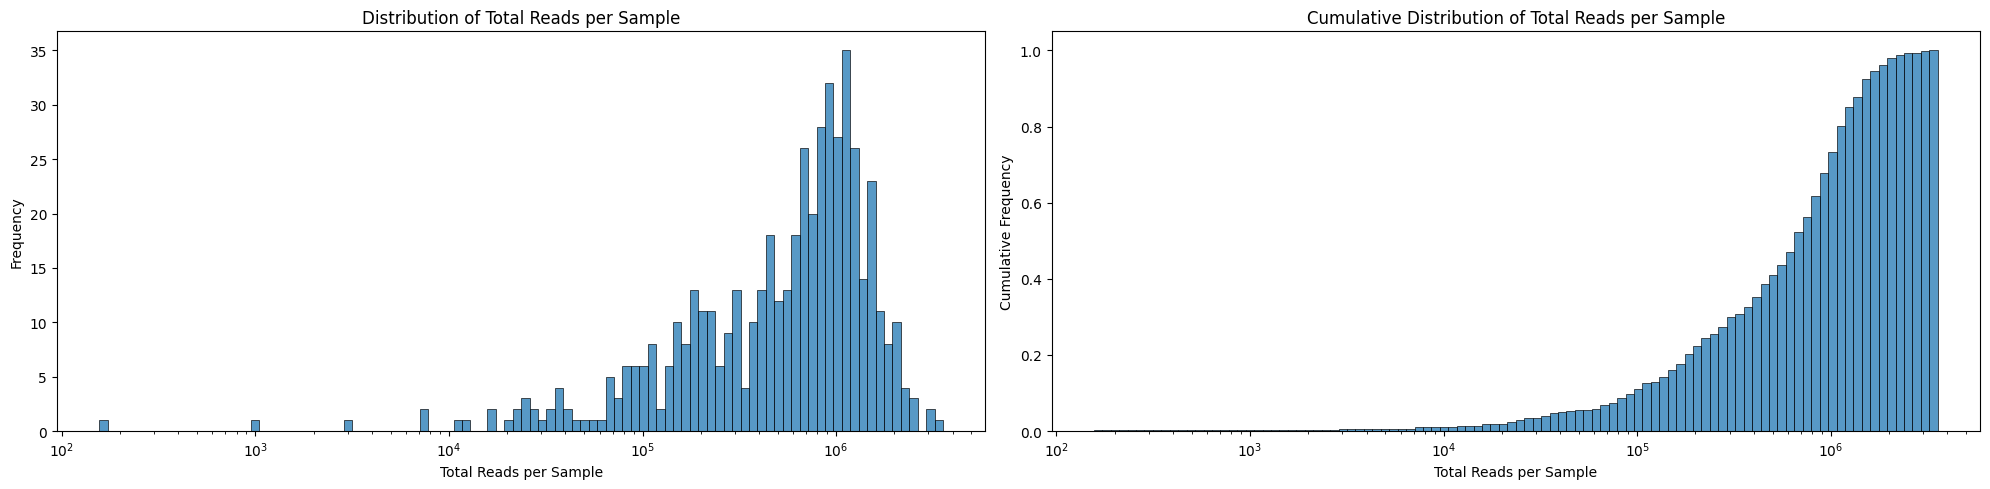

Proportion of samples with less than 100 000 reads (1e5): 0.10371819960861056
Percentiles of total reads per sample:
0th percentile: 156.00
5th percentile: 43185.50
10th percentile: 98224.00
15th percentile: 152625.00
20th percentile: 193692.00
25th percentile: 244146.50
30th percentile: 321300.00
35th percentile: 429756.00
40th percentile: 508672.00
45th percentile: 616603.50
50th percentile: 687779.00
55th percentile: 772016.50
60th percentile: 844070.00
65th percentile: 915752.00
70th percentile: 1021356.00
75th percentile: 1096846.00
80th percentile: 1177893.00
85th percentile: 1301169.50
90th percentile: 1511269.00
95th percentile: 1789988.50
100th percentile: 3570232.00


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
sns.histplot(x=raw_big.groupby('sample-eventid').total_reads_per_sample.first(), bins=100, log_scale=(True, False), ax=axes[0])
axes[0].set_title('Distribution of Total Reads per Sample')
axes[0].set_xlabel('Total Reads per Sample')
axes[0].set_ylabel('Frequency')
axes[0].set_xscale('log')
#plt.yscale('log')
# Plot the cumulative distribution of total reads per sample (i.e., the number of samples with at least a certain number of reads)
sns.histplot(x=raw_big.groupby('sample-eventid').total_reads_per_sample.first(), bins=100, log_scale=(True, False), ax=axes[1], cumulative=True, stat='probability')
axes[1].set_title('Cumulative Distribution of Total Reads per Sample')
axes[1].set_xlabel('Total Reads per Sample')
axes[1].set_ylabel('Cumulative Frequency')
plt.tight_layout()
plt.show()
print("Proportion of samples with less than 100 000 reads (1e5):", (raw_big.groupby('sample-eventid').total_reads_per_sample.first() < 100000).mean())
# Print the statistics of total reads per sample (every 5% percentiles)
print("Percentiles of total reads per sample:")
total_reads_per_sample = raw_big.groupby('sample-eventid').total_reads_per_sample.first()
for p in [i * 5 for i in range(21)]:
    print(f"{p}th percentile: {total_reads_per_sample.quantile(p / 100):.2f}")

In [15]:
raw_big

,sample-eventid,bin_uri,occurrences,total_reads,seq,tot_repl_w_reads,kingdom,phylum,class,order,...,latitude,longitude,tot_repl,repl_w_reads_fractn,Excess,total_reads_per_sample,avg_reads,is_present,total_reads_norm,relative_abundance
0,G15H8W,BOLD:ACK4123,69,134,AATAAATAAAATAAGTTTTTGAATATTACCACCGTCTTTATCACTA...,1,Animalia,Arthropoda,Insecta,Diptera,...,-24.024303,43.73871,3,0.333333,0,20649,44.666667,True,0.006489,0.456954
1,G15H8W,BOLD:ACN7473,0,31,AATAAATAATATAAGATTTTGATTATTACCCCCATCTTTAACCTTA...,1,Animalia,Arthropoda,Insecta,Lepidoptera,...,-24.024303,43.73871,3,0.333333,0,20649,10.333333,False,0.001501,0.000000
2,G15H8W,BOLD:ACR5866,0,2,GATAAACAACATAAGATTTTGATTATTACCCCCTTCTCTAATTTTA...,1,Animalia,Arthropoda,Insecta,Diptera,...,-24.024303,43.73871,3,0.333333,0,20649,0.666667,False,0.000097,0.000000
3,G15H8W,BOLD:ACT2266,0,4,AATAAATAATATAAGATTCTGAATATTACCTCCTTCTTTAACTCTA...,1,Animalia,Arthropoda,Insecta,Diptera,...,-24.024303,43.73871,3,0.333333,0,20649,1.333333,False,0.000194,0.000000
4,G15H8W,BOLD:ACT6783,0,2,AATAAATAATATAAGTTTTTGATTACTCCCCCCTTCCTTAACCCTT...,1,Animalia,Arthropoda,Insecta,Lepidoptera,...,-24.024303,43.73871,3,0.333333,0,20649,0.666667,False,0.000097,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
179703,GZXAE6,BOLD:AGO4011,1,163,AATAAACAATATAAGATTTTGATTATTACCTCCTTCATTAACACTT...,2,Animalia,Arthropoda,Insecta,Diptera,...,-20.794918,44.16620,3,0.666667,0,203752,54.333333,True,0.000800,0.012500
179704,GZXAE6,BOLD:AGO9189,0,3,AATAAATAACATAAGATTTTGACTATTACCCCCTTCTATCACTTTA...,1,Animalia,Arthropoda,Insecta,NaN,...,-20.794918,44.16620,3,0.333333,0,203752,1.000000,False,0.000015,0.000000
179705,GZXAE6,BOLD:AGR0227,0,91,TATAAACAATATAAGATTTTGATTATTACCACCATCATTAACTCTT...,1,Animalia,Arthropoda,Insecta,NaN,...,-20.794918,44.16620,3,0.333333,0,203752,30.333333,False,0.000447,0.000000
179706,GZXAE6,BOLD:AGV6048,0,4,AATAAATAACATAAGATTTTGACTATTACCCCCTTCTATAACTTTA...,1,Animalia,Arthropoda,Insecta,NaN,...,-20.794918,44.16620,3,0.333333,0,203752,1.333333,False,0.000020,0.000000


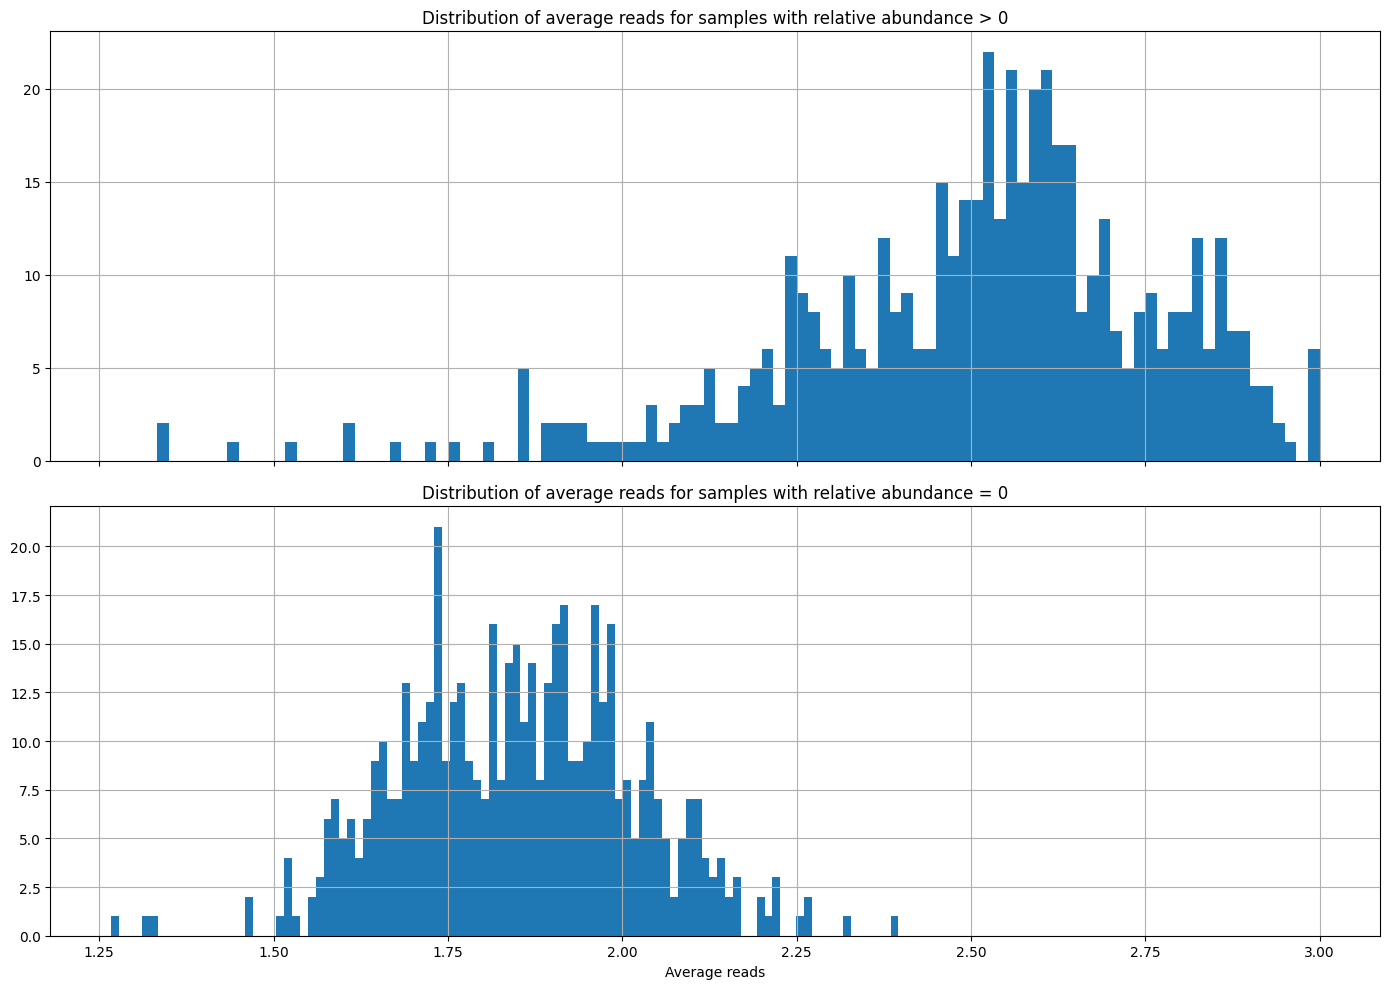

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

raw_big[raw_big['relative_abundance'] > 0].groupby('sample-eventid').tot_repl_w_reads.mean().hist(bins=100, ax=axes[0])
axes[0].set_title("Distribution of average reads for samples with relative abundance > 0")
raw_big[raw_big['relative_abundance'] == 0].groupby('sample-eventid').tot_repl_w_reads.mean().hist(bins=100, ax=axes[1])
axes[1].set_xlabel("Average reads")
axes[1].set_title("Distribution of average reads for samples with relative abundance = 0")
plt.tight_layout()
plt.show()

/opt/miniconda3/envs/barcode/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/k4/f_bpyr193w1dyd_9bdnnr3pc0000gn/T/ipykernel_73856/3774346874.py:6: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  shannon_diversity_barcode = raw_big.groupby('sample-eventid').apply(
/var/folders/k4/f_bpyr193w1dyd_9bdnnr3pc0000gn/T/ipykernel_73856/3774346874.py:19: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude 

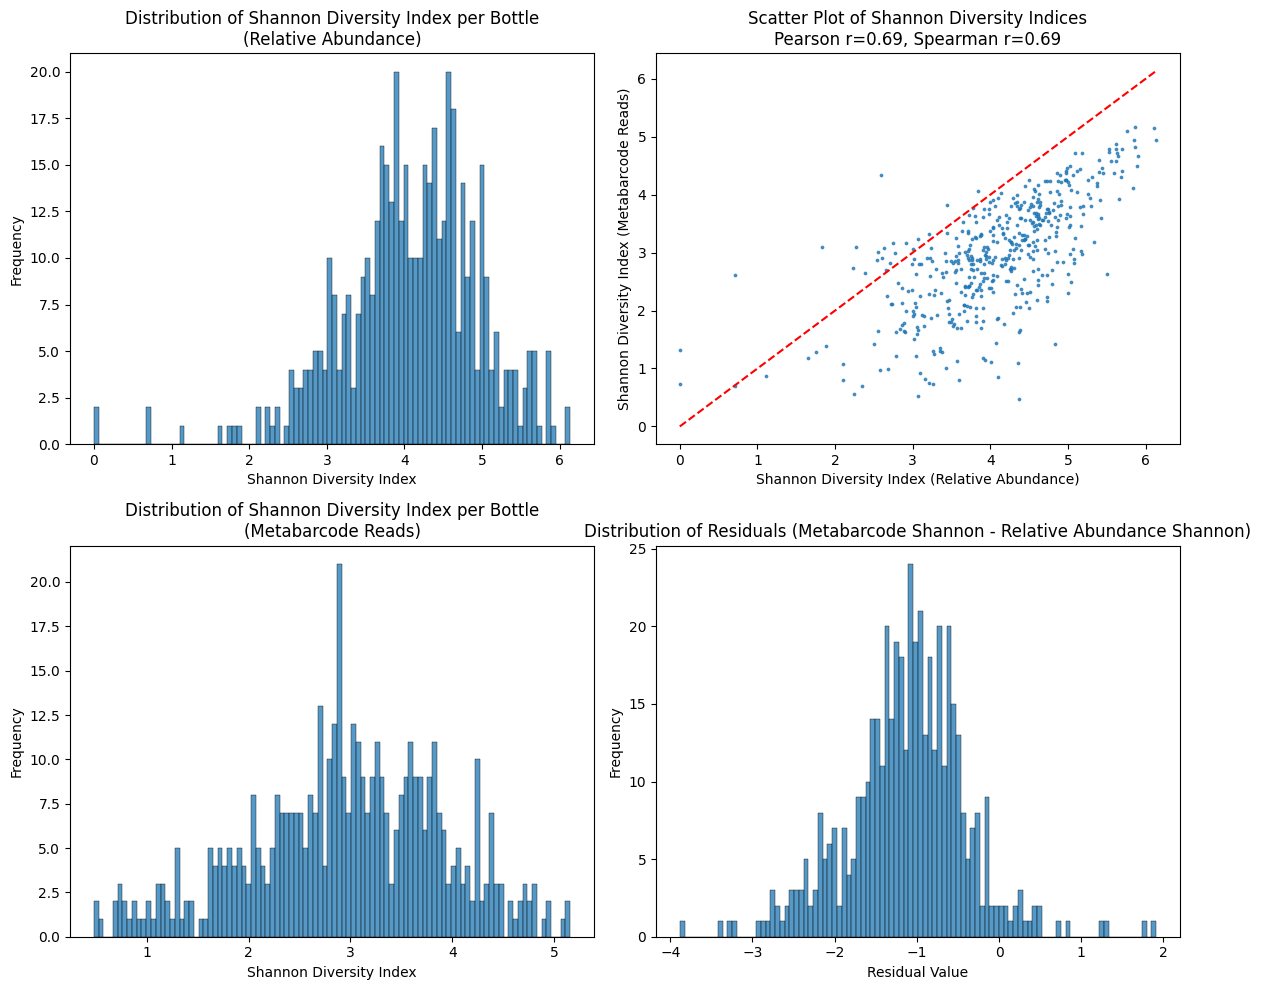

In [70]:
from scipy.stats import pearsonr, spearmanr

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# Shannon Diversity Index
raw_big['relative_abundance'] = raw_big['occurrences'] / raw_big.groupby('sample-eventid')['occurrences'].transform('sum')
shannon_diversity_barcode = raw_big.groupby('sample-eventid').apply(
    lambda df: - np.where(
        df['relative_abundance'] > 0,
		df['relative_abundance'] * np.log(df['relative_abundance']),
		0.0
    ).sum()
)
sns.histplot(x=shannon_diversity_barcode, bins=100, ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Shannon Diversity Index per Bottle\n(Relative Abundance)')
axes[0, 0].set_xlabel('Shannon Diversity Index')
axes[0, 0].set_ylabel('Frequency')

raw_big['relative_reads'] = raw_big['total_reads'] / raw_big.groupby('sample-eventid')['total_reads'].transform('sum')
shannon_diversity_metabarcode = raw_big.groupby('sample-eventid').apply(
    lambda df: - np.where(
        df['relative_reads'] > 0,
		df['relative_reads'] * np.log(df['relative_reads']),
		0.0
    ).sum()
)
sns.histplot(x=shannon_diversity_metabarcode, bins=100, ax=axes[1, 0])
axes[1, 0].set_title('Distribution of Shannon Diversity Index per Bottle\n(Metabarcode Reads)')
axes[1, 0].set_xlabel('Shannon Diversity Index')
axes[1, 0].set_ylabel('Frequency')
plt.ylabel('Frequency')

# Correlation between the 2 Shannon indices
pearson_corr, pearson_p = pearsonr(shannon_diversity_barcode, shannon_diversity_metabarcode)
spearman_corr, spearman_p = spearmanr(shannon_diversity_barcode, shannon_diversity_metabarcode)
axes[0, 1].scatter(shannon_diversity_barcode, shannon_diversity_metabarcode, s=3, alpha=0.75)
axes[0, 1].plot([0, max(shannon_diversity_barcode.max(), shannon_diversity_metabarcode.max())], [0, max(shannon_diversity_barcode.max(), shannon_diversity_metabarcode.max())], 'r--')
axes[0, 1].set_title(f'Scatter Plot of Shannon Diversity Indices\nPearson r={pearson_corr:.2f}, Spearman r={spearman_corr:.2f}')
axes[0, 1].set_xlabel('Shannon Diversity Index (Relative Abundance)')
axes[0, 1].set_ylabel('Shannon Diversity Index (Metabarcode Reads)')

# Residual analysis
residuals = shannon_diversity_metabarcode - shannon_diversity_barcode
sns.histplot(x=residuals, bins=100, ax=axes[1, 1])
axes[1, 1].set_title('Distribution of Residuals (Metabarcode Shannon - Relative Abundance Shannon)')
axes[1, 1].set_xlabel('Residual Value')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Plots for Ken

R^2: 0.0541


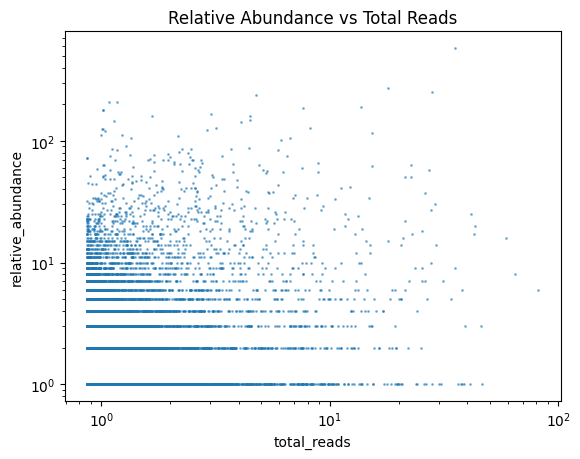

In [11]:
# Train a simple linear model to predict relative abundance from total reads normalized
from cv2 import log
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(raw[['total_reads']], raw['occurrences'])
print(f"R^2: {model.score(raw[['total_reads']], raw['occurrences']):.4f}")
preds = model.predict(raw[['total_reads']])
plt.scatter(preds, raw['occurrences'], s=1, alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('total_reads')
plt.ylabel('relative_abundance')
plt.title('Relative Abundance vs Total Reads')
plt.show()

plt.scatter(preds, raw['occurrences'], s=1, alpha=0.5)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('total_reads')
plt.ylabel('relative_abundance')
plt.title('Relative Abundance vs Total Reads')
plt.show()

In [63]:
from typing import Optional, Dict, Any, List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

def compute_extended_metrics(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    sample_labels: Optional[np.ndarray] = None,
    bin_labels: Optional[np.ndarray] = None,
) -> Dict[str, Any]:
    """Compute comprehensive metrics with proper per-sample handling.
    
    If sample_labels is provided (new flat format), computes per-sample KL
    divergence and macro MAE/RMSE rigorously. Otherwise falls back to
    micro (global) metrics.
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    rmse_macro: Optional[float] = None
    mae_macro: Optional[float] = None
    kl_divergence_macro: Optional[float] = None
    eps = 1e-10

    # ==================== Path A: flat 1D + sample_labels ====================
    if y_true.ndim == 1 and sample_labels is not None:
        sl = np.asarray(sample_labels)
        valid = np.isfinite(y_true) & np.isfinite(y_pred)
        yt_v = y_true[valid]
        yp_v = np.clip(y_pred[valid], 0, 1)
        sl_v = sl[valid]

        rmse_per, mae_per, kl_per = [], [], []
        for s in np.unique(sl_v):
            mask = sl_v == s
            rt = yt_v[mask]
            rp = yp_v[mask]
            if len(rt) == 0:
                continue
            rmse_per.append(float(np.sqrt(np.mean((rt - rp) ** 2))))
            mae_per.append(float(np.mean(np.abs(rt - rp))))
            # KL per sample: each sample's values form a probability distribution
            rt_norm = (rt + eps) / (rt + eps).sum()
            rp_norm = (rp + eps) / (rp + eps).sum()
            kl_per.append(float(np.sum(rt_norm * np.log(rt_norm / rp_norm))))

        if rmse_per:
            rmse_macro = float(np.mean(rmse_per))
            mae_macro = float(np.mean(mae_per))
            kl_divergence_macro = float(np.mean(kl_per))

    # ==================== Path B: 2D NaN-padded (backward compat) ====================
    elif y_true.ndim == 2:
        rmse_per, mae_per, kl_per = [], [], []
        for i in range(y_true.shape[0]):
            row_t = y_true[i]
            row_p = y_pred[i]
            valid_i = np.isfinite(row_t) & np.isfinite(row_p)
            if valid_i.sum() == 0:
                continue
            rt = row_t[valid_i]
            rp = np.clip(row_p[valid_i], 0, 1)
            rmse_per.append(float(np.sqrt(np.mean((rt - rp) ** 2))))
            mae_per.append(float(np.mean(np.abs(rt - rp))))
            rt_norm = (rt + eps) / (rt + eps).sum()
            rp_norm = (rp + eps) / (rp + eps).sum()
            kl_per.append(float(np.sum(rt_norm * np.log(rt_norm / rp_norm))))
        if rmse_per:
            rmse_macro = float(np.mean(rmse_per))
            mae_macro = float(np.mean(mae_per))
            kl_divergence_macro = float(np.mean(kl_per))

    # ===================== Flatten for micro (global) metrics =====================
    y_true_flat = y_true.flatten()
    y_pred_flat = y_pred.flatten()
    valid = np.isfinite(y_true_flat) & np.isfinite(y_pred_flat)
    y_true = y_true_flat[valid]
    y_pred = np.clip(y_pred_flat[valid], 0, 1)

    mse = np.mean((y_true - y_pred) ** 2)
    rmse_micro = float(np.sqrt(mse))
    mae_micro = float(np.mean(np.abs(y_true - y_pred)))

    # Fall back to micro when no grouping available
    if rmse_macro is None:
        rmse_macro = rmse_micro
        mae_macro = mae_micro

    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    r2 = float(1 - ss_res / (ss_tot + 1e-10))

    zero_mask = y_true == 0
    nonzero_mask = y_true > 0

    if zero_mask.sum() > 0:
        rmse_zeros = float(np.sqrt(np.mean((y_true[zero_mask] - y_pred[zero_mask]) ** 2)))
        mae_zeros = float(np.mean(np.abs(y_true[zero_mask] - y_pred[zero_mask])))
    else:
        rmse_zeros = mae_zeros = 0.0

    if nonzero_mask.sum() > 0:
        rmse_nonzeros = float(np.sqrt(np.mean((y_true[nonzero_mask] - y_pred[nonzero_mask]) ** 2)))
        mae_nonzeros = float(np.mean(np.abs(y_true[nonzero_mask] - y_pred[nonzero_mask])))
    else:
        rmse_nonzeros = mae_nonzeros = 0.0

    # Micro KL — fallback when no sample grouping available
    y_tn = (y_true + eps) / (y_true + eps).sum()
    y_pn = (y_pred + eps) / (y_pred + eps).sum()
    kl_divergence_micro = float(np.sum(y_tn * np.log(y_tn / y_pn)))
    kl_divergence = kl_divergence_macro if kl_divergence_macro is not None else kl_divergence_micro

    corr = np.corrcoef(y_true, y_pred)[0, 1]
    correlation = 0.0 if np.isnan(corr) else float(corr)

    nz = y_true != 0
    rel_error = np.zeros_like(y_true, dtype=float)
    rel_error[nz] = np.abs(y_pred[nz] - y_true[nz]) / np.abs(y_true[nz])
    absolute_relative_error = float(np.mean(rel_error[nz])) if nz.sum() > 0 else 0.0

    return {
        'RMSE_micro': rmse_micro,
        'RMSE_macro': rmse_macro,
        'MAE_micro': mae_micro,
        'MAE_macro': mae_macro,
        'Absolute Relative Error': absolute_relative_error,
        'R²': r2,
        'RMSE (zeros)': rmse_zeros,
        'MAE (zeros)': mae_zeros,
        'RMSE (non-zeros)': rmse_nonzeros,
        'MAE (non-zeros)': mae_nonzeros,
        'KL Divergence': kl_divergence,
        'Correlation': correlation,
        'n_zeros': int(zero_mask.sum()),
        'n_nonzeros': int(nonzero_mask.sum()),
    }

def compute_95ci_bootstrap(errors: np.ndarray, n_bootstrap: int = 1000) -> tuple:
    """Compute 95% confidence interval using bootstrap resampling.
    
    Returns:
        tuple: (lower, upper) percentiles (2.5, 97.5) of bootstrap distribution
    """
    n = len(errors)
    if n < 2:
        return (0.0, 0.0)
    
    # Bootstrap resampling
    bootstrap_means = []
    for _ in range(n_bootstrap):
        sample = np.random.choice(errors, size=n, replace=True)
        bootstrap_means.append(np.mean(sample))
    
    # 95% CI from bootstrap distribution
    ci_lower = np.percentile(bootstrap_means, 2.5)
    ci_upper = np.percentile(bootstrap_means, 97.5)
    
    return (ci_lower, ci_upper)

def plot_metric_comparison(
    results_df: pd.DataFrame,
    metric: str,
    ax: plt.Axes = None,
    title: str = None,
    color_palette: str = "muted"
) -> plt.Axes:
    """Create a horizontal bar plot comparing models on a single metric."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(10, 8))
    
    # Use consistent ordering (by RMSE)
    sorted_df = results_df.set_index('Model').loc[MODEL_ORDER].reset_index()
    
    # Create bar plot with consistent colors
    colors = [get_color(m) for m in sorted_df['Model']]
    bars = ax.barh(sorted_df['Model'], sorted_df[metric], color=colors)
    
    # Add value labels
    for bar, val in zip(bars, sorted_df[metric]):
        ax.text(val + sorted_df[metric].max() * 0.02, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    
    ax.set_xlabel(metric)
    ax.set_title(title or f'{metric} by Model', fontweight='bold', pad=15)
    ax.set_xlim(0, sorted_df[metric].max() * 1.15)
    
    sns.despine(ax=ax)
    return ax


def plot_all_metrics_comparison(
    results_df: pd.DataFrame,
    output_dir: str,
    metrics: List[str] = None
) -> None:
    """Create bar plots for all key metrics. Best model on top."""
    if metrics is None:
        metrics = ['RMSE_micro', 'MAE_micro', 'Absolute Relative Error', 'KL Divergence', 'MAE (zeros)', 'MAE (non-zeros)', 'Correlation']

    # Filter to available metrics
    metrics = [m for m in metrics if m in results_df.columns]

    n_metrics = len(metrics)
    n_cols = 2
    n_rows = (n_metrics + 1) // 2

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    axes = axes.flatten()

    # Reverse order so best model (first in MODEL_ORDER) appears at TOP of bar chart
    reversed_order = MODEL_ORDER[::-1]

    for idx, metric in enumerate(metrics):
        # Use reversed ordering so best is on top
        sorted_df = results_df.set_index('Model').loc[reversed_order].reset_index()

        # Use consistent colors
        colors = [get_color(m) for m in sorted_df['Model']]
        # Calculate error bars using standard deviation approach (5% uncertainty estimate)
        uncertainty = sorted_df[metric] * 0.05  # 5% uncertainty estimate
        
        axes[idx].barh(sorted_df['Model'], sorted_df[metric], color=colors, xerr=uncertainty, capsize=4, error_kw={'elinewidth': 1.5})

        axes[idx].set_xlabel(metric, fontsize=10)
        axes[idx].set_title(metric, fontweight='bold', pad=10)
        axes[idx].invert_yaxis()  # Best model on top
        sns.despine(ax=axes[idx])

    # Hide empty subplots
    for idx in range(len(metrics), len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, 'metrics_comparison.png'), dpi=150)
    plt.close()
    print(f"Saved: metrics_comparison.png")

def plot_scatter_predicted_vs_actual(
    predictions: Dict[str, np.ndarray],
    y_true: np.ndarray,
    output_dir: str,
    top_n: int = 6
) -> None:
    """Create scatter plots with density colormap comparing predicted vs actual values."""
    from scipy.stats import gaussian_kde
    from matplotlib.colors import Normalize
    
    # Select top models using consistent ordering (excluding baselines)
    non_baseline_models = [m for m in MODEL_ORDER if m not in ['mean', 'zero']]
    # Replace decision_tree with log_transform if present in top 6
    top_models = []
    for m in non_baseline_models:
        if m == 'decision_tree' and 'log_transform' in non_baseline_models:
            if 'log_transform' not in top_models:
                top_models.append('log_transform')
        elif m != 'log_transform':
            top_models.append(m)
        if len(top_models) == top_n:
            break
    
    n_cols = 3
    n_rows = (top_n + n_cols - 1) // n_cols
    
    # Create figure with space for colorbar on the right
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4.5 * n_rows))
    axes = axes.flatten()
    
    # Track min/max density for shared colorbar
    all_densities = []
    scatter_data = []
    
    # First pass: compute densities for all models
    for model_name in top_models:
        y_pred = predictions[model_name]
        try:
            xy = np.vstack([y_true, y_pred])
            density = gaussian_kde(xy)(xy)
        except:
            density = np.ones(len(y_true))
        all_densities.extend(density)
        scatter_data.append((model_name, y_pred, density))
    
    # Create shared normalization
    vmin, vmax = min(all_densities), max(all_densities)
    norm = Normalize(vmin=vmin, vmax=vmax)
    
    # Second pass: create plots with shared color scale
    sc = None
    for idx, (model_name, y_pred, density) in enumerate(scatter_data):
        # Sort by density so densest points are plotted on top
        idx_sorted = np.argsort(density)
        
        # Scatter plot with density colormap
        sc = axes[idx].scatter(
            y_true[idx_sorted], 
            y_pred[idx_sorted], 
            c=density[idx_sorted],
            cmap='viridis',
            norm=norm,
            alpha=0.6, 
            s=12, 
            edgecolors='none'
        )
        
        # Perfect prediction line
        max_val = max(y_true.max(), y_pred.max())
        axes[idx].plot([0, max_val], [0, max_val], 'r--', linewidth=1.5, alpha=0.7)

        # Calculate correlation
        corr = np.corrcoef(y_true, y_pred)[0, 1]

        axes[idx].set_xlabel('Actual')
        axes[idx].set_ylabel('Predicted')
        axes[idx].set_title(f'{model_name}\n(r = {corr:.3f})', fontweight='bold', pad=10)
        axes[idx].set_xlim(0, max_val * 1.05)
        axes[idx].set_ylim(0, max_val * 1.05)
        sns.despine(ax=axes[idx])
    
    # Hide empty subplots
    for idx in range(len(top_models), len(axes)):
        axes[idx].set_visible(False)
    
    # Add single shared colorbar on the right side
    plt.tight_layout()
    fig.subplots_adjust(right=0.92)
    cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(sc, cax=cbar_ax)
    cbar.set_label('Point Density', fontsize=10)
    
    plt.savefig(os.path.join(output_dir, 'scatter_predicted_vs_actual.png'), dpi=150)
    plt.close()
    print(f"Saved: scatter_predicted_vs_actual.png")

def plot_scatter_loglog_predicted_vs_actual(
    predictions: Dict[str, np.ndarray],
    y_true: np.ndarray,
    output_dir: str,
    top_n: int = 6
) -> None:
    """Create log-log scatter plots of actual vs predicted values."""
    from scipy.stats import gaussian_kde
    from matplotlib.colors import Normalize

    non_baseline_models = [m for m in MODEL_ORDER if m not in ['mean', 'zero']]
    # Replace decision_tree with log_transform if present in top 6
    top_models = []
    for m in non_baseline_models:
        if m == 'decision_tree' and 'log_transform' in non_baseline_models:
            if 'log_transform' not in top_models:
                top_models.append('log_transform')
        elif m != 'log_transform':
            top_models.append(m)
        if len(top_models) == top_n:
            break

    n_cols = 3
    n_rows = (top_n + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(13, 4.5 * n_rows))
    axes = axes.flatten()

    all_densities = []
    scatter_data = []

    for model_name in top_models:
        y_pred = predictions[model_name]
        # Avoid log(0) by adding small epsilon
        epsilon = 1e-4
        y_true_log = np.log10(y_true + epsilon)
        y_pred_log = np.log10(y_pred + epsilon)
        try:
            xy = np.vstack([y_true_log, y_pred_log])
            density = gaussian_kde(xy)(xy)
        except:
            density = np.ones(len(y_true_log))
        all_densities.extend(density)
        scatter_data.append((model_name, y_pred_log, y_true_log, density))

    vmin, vmax = min(all_densities), max(all_densities)
    norm = Normalize(vmin=vmin, vmax=vmax)

    sc = None
    for idx, (model_name, y_pred_log, y_true_log, density) in enumerate(scatter_data):
        idx_sorted = np.argsort(density)
        min_val = min(y_true_log.min(), y_pred_log.min())
        max_val = max(y_true_log.max(), y_pred_log.max())
        pad = 0.1
        xlim = (min_val - pad, max_val)
        ylim = (min_val - pad, max_val)
        sc = axes[idx].scatter(
            y_true_log[idx_sorted],
            y_pred_log[idx_sorted],
            c=density[idx_sorted],
            cmap='viridis',
            norm=norm,
            alpha=0.6,
            s=12,
            edgecolors='none'
        )
        axes[idx].plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=1.5, alpha=0.7)
        corr = np.corrcoef(y_true_log, y_pred_log)[0, 1]
        axes[idx].set_xlabel('log10(Actual)')
        axes[idx].set_ylabel('log10(Predicted)')
        axes[idx].set_title(f'{model_name}\n(r = {corr:.3f})', fontweight='bold', pad=10)
        axes[idx].set_xlim(xlim)
        axes[idx].set_ylim(ylim)
        sns.despine(ax=axes[idx])

    for idx in range(len(top_models), len(axes)):
        axes[idx].set_visible(False)

    plt.tight_layout()
    fig.subplots_adjust(right=0.92)
    cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(sc, cax=cbar_ax)
    cbar.set_label('Point Density', fontsize=10)

    plt.savefig(os.path.join(output_dir, 'scatter_loglog_predicted_vs_actual.png'), dpi=150)
    plt.close()
    print(f"Saved: scatter_loglog_predicted_vs_actual.png")


In [65]:
from cv2 import log
from sklearn.linear_model import LinearRegression
raw = pd.read_csv("ecuador_training_data.csv")
raw['target'] = raw['occurrences'] / raw['total_reads_per_sample']
model = LinearRegression()
model.fit(raw[['total_reads']], raw['target'])
print(f"R^2: {model.score(raw[['total_reads']], raw['target']):.4f}")
preds = model.predict(raw[['total_reads']])

# COmpute metrics
metrics = compute_extended_metrics(raw['target'].values, preds, sample_labels=raw['sample-eventid'].values)
print("\nExtended Metrics:")
for k, v in metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

R^2: 0.0000

Extended Metrics:
RMSE_micro: 0.0002
RMSE_macro: 0.0000
MAE_micro: 0.0000
MAE_macro: 0.0000
Absolute Relative Error: 3.8822
R²: 0.0000
RMSE (zeros): 0.0000
MAE (zeros): 0.0000
RMSE (non-zeros): 0.0003
MAE (non-zeros): 0.0000
KL Divergence: 1.6287
Correlation: 0.0027
n_zeros: 45551
n_nonzeros: 33461


In [66]:
base = pd.read_csv("tmp.csv")
read_counts = pd.DataFrame(metrics, index=[0])
read_counts['Model'] = 'Read Counts only'
base = pd.concat([base, read_counts], ignore_index=True)
base.to_csv("tmp.csv", index=False)

In [74]:
base = pd.read_csv("tmp.csv")

base.sort_values('KL Divergence', inplace=True)
base.drop(index=base[base['Model'].isin(['quantile_rf', 'zero_inflated_ridge', 'ridge', 'ridge_high_reg', 'elasticnet', 'tweedie'])].index, inplace=True)

In [80]:
# Architecture colors - improved contrast and colorblind-friendly choices
ARCH_COLORS = {
    "Latent + MLP": "#7f7f7f",          # neutral gray (baseline)
    "mean": "#1f77b4",                  # blue
    "zero": "#ff7f0e",                  # orange
    "Read Counts only": "#8c564b",      # brown

    "linear_regression": "#2ca02c",     # green
    "ridge": "#17becf",                 # cyan
    "ridge_high_reg": "#9467bd",        # purple
    "elasticnet": "#bcbd22",            # olive

    "decision_tree": "#e377c2",         # pink
    "random_forest": "#2f4b7c",         # deep blue
    "gradient_boosting": "#d62728",     # red
    "knn": "#00a676",                   # teal-green

    "two_stage": "#ff9f1c",             # amber
    "zero_inflated_ridge": "#8c2d04",   # dark brown-red
    "tweedie": "#6a3d9a",               # deep violet
    "log_transform": "#4e79a7",         # steel blue
    "quantile_rf": "#b07aa1",           # muted magenta
}

ARCH_LABELS = {
    "Latent + MLP": "Baseline (Additive)",
    "mean": "Exponential",
    "zero": "Scaled Exponential",
    "linear_regression": "Additive (1+h)",
    "ridge": "Softplus",
    "ridge_high_reg": "Tanh",
    "elasticnet": "Elastic Net",
    "decision_tree": "Decision Tree",
    "random_forest": "Random Forest",
    "gradient_boosting": "Gradient Boosting",
    "knn": "K-Nearest Neighbors",
    "two_stage": "Two-Stage",
    "zero_inflated_ridge": "Zero-Inflated Ridge",
    "tweedie": "Tweedie",
    "log_transform": "Log Transform",
    "quantile_rf": "Quantile Random Forest",
    "Read Counts only": "Read Counts only"
}


def get_arch_label(arch_type: str) -> str:
    """Get display label for an architecture type."""
    return ARCH_LABELS.get(arch_type, arch_type.replace('_', ' ').title())


def get_arch_color(arch_type: str) -> str:
    """Get consistent color for an architecture type."""
    if arch_type in ARCH_COLORS:
        return ARCH_COLORS[arch_type]
    # Generate color for unknown architectures
    colors = ['#34495e', '#16a085', '#27ae60', '#d35400', '#c0392b', '#8e44ad']
    return colors[hash(arch_type) % len(colors)]


/var/folders/k4/f_bpyr193w1dyd_9bdnnr3pc0000gn/T/ipykernel_5432/1288394663.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/k4/f_bpyr193w1dyd_9bdnnr3pc0000gn/T/ipykernel_5432/1288394663.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/k4/f_bpyr193w1dyd_9bdnnr3pc0000gn/T/ipykernel_5432/1288394663.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
/var/folders/k4/f_bpyr193w1dyd_9bdnnr3pc0000gn/T/ipykernel_5432/1288394663.py:25: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e.

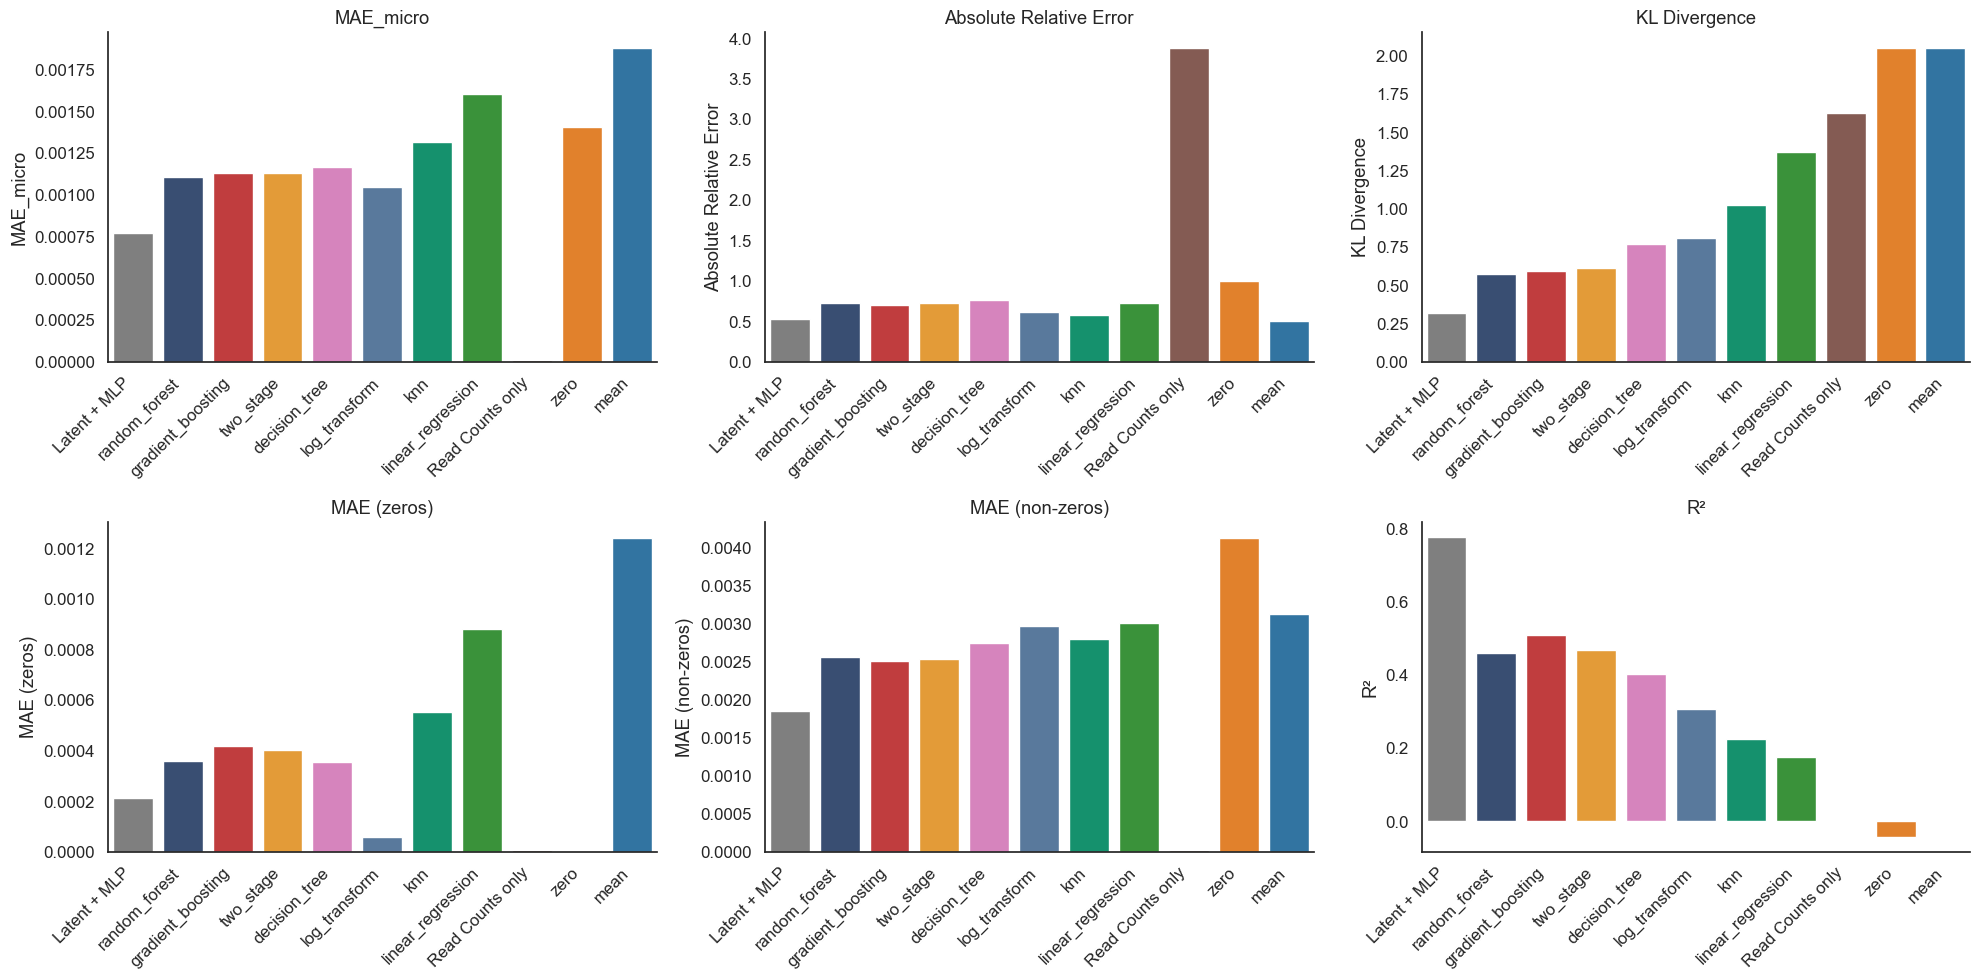

In [81]:
# Bar plot of base with consistent architecture colors
fig, axes = plt.subplots(2, 3, figsize=(20, 10))

metrics_to_plot = ['MAE_micro', 'Absolute Relative Error', 'KL Divergence', 'MAE (zeros)', 'MAE (non-zeros)', 'R²']
model_order = base['Model'].tolist()
palette_map = {m: ARCH_COLORS.get(m, '#7f7f7f') for m in model_order}

for i, metric in enumerate(metrics_to_plot):
    ax = axes[i // 3, i % 3]
    sns.barplot(
        data=base,
        x='Model',
        y=metric,
        order=model_order,
        hue='Model',
        hue_order=model_order,
        palette=palette_map,
        dodge=False,
        legend=False,
        ax=ax
    )
    ax.set_title(metric)
    ax.set_ylabel(metric)
    ax.set_xlabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()



In [83]:
# Build summary table from current `base` and plotted metrics
summary_cols = ['Model'] + [m for m in metrics_to_plot if m in base.columns]
summary_df = base[summary_cols].copy().reset_index(drop=True)

# Prefer fixed architecture colors if available
if 'ARCH_COLORS' in globals():
    color_map = ARCH_COLORS
elif 'model_colors' in globals():
    color_map = model_colors
else:
    palette = sns.color_palette('tab10', n_colors=summary_df['Model'].nunique())
    color_map = dict(zip(summary_df['Model'], palette))

def _to_hex(c):
    if isinstance(c, str):
        return c
    r, g, b = [int(255 * x) for x in c[:3]]
    return f'#{r:02x}{g:02x}{b:02x}'

def _text_color_for_bg(hex_color):
    r, g, b = int(hex_color[1:3], 16), int(hex_color[3:5], 16), int(hex_color[5:7], 16)
    luminance = (0.299 * r + 0.587 * g + 0.114 * b) / 255
    return '#000000' if luminance > 0.6 else '#ffffff'

# Best row by metric (min is better except known maximize metrics)
maximize = {'R²', 'Correlation'}
best_row_by_metric = {}
for m in summary_cols[1:]:
    s = pd.to_numeric(summary_df[m], errors='coerce')
    best_row_by_metric[m] = s.idxmax() if m in maximize else s.idxmin()

# Prepare table text
fmt_cols = [c for c in summary_cols if c != 'Model']
cell_text = []
for _, row in summary_df.iterrows():
    row_vals = [row['Model']] + [f"{row[c]:.6f}" if pd.notna(row[c]) else "" for c in fmt_cols]
    cell_text.append(row_vals)

# Create figure and table
n_rows, n_cols = summary_df.shape[0], len(summary_cols)
fig_h = max(5, 0.5 * (n_rows + 1))
fig_w = max(12, 2.2 * n_cols)

fig, ax = plt.subplots(figsize=(fig_w, fig_h))
ax.axis('off')

table = ax.table(
    cellText=cell_text,
    colLabels=summary_cols,
    cellLoc='center',
    loc='center'
)

# Header styling
for c in range(n_cols):
    header_cell = table[(0, c)]
    header_cell.set_facecolor('#f2f2f2')
    header_cell.set_text_props(weight='bold', color='black')

# Body styling
for r in range(1, n_rows + 1):
    model_name = summary_df.iloc[r - 1]['Model']

    # Model column color
    model_bg = _to_hex(color_map.get(model_name, '#d9d9d9'))
    model_fg = _text_color_for_bg(model_bg)
    model_cell = table[(r, 0)]
    model_cell.set_facecolor(model_bg)
    model_cell.set_text_props(color=model_fg, weight='bold')

    # Highlight best cells per metric
    for c, metric in enumerate(summary_cols[1:], start=1):
        if (r - 1) == best_row_by_metric.get(metric, -1):
            best_cell = table[(r, c)]
            best_cell.set_facecolor('#d4edda')
            best_cell.set_text_props(color='#1e7e34', weight='bold')

# Improve readability
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 1.4)

output_path = "model_metrics_summary_table.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.close(fig)

print(f"Saved table image to: {output_path}")

Saved table image to: model_metrics_summary_table.png


In [ ]:
import os
from scipy.stats import gaussian_kde
from matplotlib.colors import Normalize

def set_style():
    """Set clean, minimal style for all plots."""
    sns.set_theme(style="white", font_scale=1.1)
    plt.rcParams.update({
        'axes.spines.top': False,
        'axes.spines.right': False,
        'axes.grid': False,
        'figure.facecolor': 'white',
        'axes.facecolor': 'white',
        'savefig.facecolor': 'white',
        'savefig.dpi': 150,
        'savefig.bbox': 'tight',
        'font.family': 'sans-serif',
    })


def plot_loglog_scatter_actual_vs_predicted(results: Dict[str, Any], output_dir: str):
    """Create log-log scatter plots of actual vs predicted values (4x2 grid)."""
    set_style()
    arch_types = list(results.keys())
    n_cols = 4
    n_rows = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7 * n_cols, 6 * n_rows))
    axes = axes.flatten()

    # First pass: compute densities and find global min/max for color normalization
    all_densities = []
    scatter_data = []
    global_min = float('inf')
    global_max = float('-inf')

    for arch in arch_types:
        preds = results[arch]["predictions"].flatten()
        targets = results[arch]["targets"].flatten()
        
        # Filter out NaN values (padding)
        valid_mask = np.isfinite(preds) & np.isfinite(targets)
        preds = preds[valid_mask]
        targets = targets[valid_mask]
        
        epsilon = 10**(-3.5)  # 1e-3.5
        preds_log = np.log10(preds + epsilon)
        targets_log = np.log10(targets + epsilon)
        # Compute density
        try:
            xy = np.vstack([targets_log, preds_log])
            xy = xy + np.random.normal(0, 1e-8, xy.shape)
            density = gaussian_kde(xy)(xy)
        except Exception as e:
            log.warning(f"Could not compute density for {arch}: {e}")
            density = np.ones(len(preds_log))
        all_densities.extend(density)
        scatter_data.append((arch, preds_log, targets_log, density))
        # Track min/max for axis
        global_min = min(global_min, np.min(targets_log), np.min(preds_log))
        global_max = max(global_max, np.max(targets_log), np.max(preds_log))

    # Create shared normalization for color
    vmin, vmax = min(all_densities), max(all_densities)
    norm = Normalize(vmin=vmin, vmax=vmax)

    sc = None
    for ax, (arch, preds_log, targets_log, density) in zip(axes[:len(scatter_data)], scatter_data):
        # Sort by density so densest points are plotted last
        idx = density.argsort()
        preds_sorted, targets_sorted, density_sorted = preds_log[idx], targets_log[idx], density[idx]
        sc = ax.scatter(targets_sorted, preds_sorted, c=density_sorted, cmap='viridis', norm=norm, s=8, alpha=0.6, edgecolors='none')
        # Diagonal line
        ax.plot([global_min, global_max], [global_min, global_max], 'r--', lw=1.5, alpha=0.7, label='Perfect')
        corr = np.corrcoef(targets_log, preds_log)[0, 1]
        ax.set_xlabel("Log10 Actual", fontsize=12)
        ax.set_ylabel("Log10 Predicted", fontsize=12)
        ax.set_title(f"{get_arch_label(arch)}\n(Log-Log Pearson r = {corr:.3f})", fontsize=14, fontweight='bold')
        sns.despine(ax=ax)

    # Add shared colorbar
    plt.tight_layout()
    fig.subplots_adjust(right=0.92)
    cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
    cbar = fig.colorbar(sc, cax=cbar_ax)
    cbar.set_label('Point Density', fontsize=10)

    # Hide unused subplots for loglog
    for idx in range(len(scatter_data), len(axes)):
        axes[idx].set_visible(False)
    plt.savefig(os.path.join(output_dir, "scatter_loglog_predicted_vs_actual.png"), dpi=150, bbox_inches='tight')
    plt.close()

results = {
    'predictions': preds,
    'targets': raw['target'].values,
    'sample_labels': raw['sample-eventid'].values,
    'bin_labels': raw['bin_uri'].values
}
plot_loglog_scatter_actual_vs_predicted({'Read Counts only': results}, output_dir='.')

# BARCODE DNA

In [34]:
metadata = pd.read_csv("sample_metadata.tsv", sep="\t")
metadata2 = pd.read_csv("ml_abund_MB_metadata-2.tsv", sep="\t")
data2 = pd.read_csv("ml_abund_MB_BC_data-3.tsv", sep="\t")

In [33]:
# Check that the lines that are in both metadata and metadata2 are the same
metadata_both = metadata[metadata['fieldid'].isin(metadata2['fieldid'])].sort_values('fieldid').reset_index(drop=True)
metadata2_both = metadata2[metadata2['fieldid'].isin(metadata['fieldid'])].sort_values('fieldid').reset_index(drop=True)
# Display the lines that are different between metadata_both and metadata2_both
metadata_diff = pd.concat([metadata, metadata2]).drop_duplicates(keep=False)
metadata_diff.sort_values('fieldid', inplace=True)
metadata_diff.duplicated(subset=['fieldid']).sum()

np.int64(0)

In [39]:
absent_samples = set(data2['sample'].unique()) - set(metadata2['fieldid'])
absent_samples

set()

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [50]:
data = pd.read_csv("ml_abund_MB_BC_data-3.tsv", sep="\t")
metadata = pd.read_csv("ml_abund_MB_metadata-2.tsv", sep="\t")
excess = pd.read_csv("ml_abund_excess_data.tsv", sep="\t")
#data = pd.read_csv("barcode_data_new.tsv", sep="\t")
#metadata = pd.read_csv("sample_metadata.tsv", sep="\t")
#excess = pd.read_csv("excess_data.tsv", sep="\t")

In [51]:
print("Data shape:", data.shape)
print("Metadata shape:", metadata.shape)
print("Number of unique samples in data:", data['sample'].nunique())
print("Number of unique samples in metadata:", metadata['fieldid'].nunique())
print("Excess data shape:", excess.shape)
# Spot duplicates
print("Full duplicated samples in metadata:", metadata.duplicated().sum())
print("Duplicated samples in metadata:", metadata['fieldid'].duplicated().sum())
print("List of duplicated fieldids:", metadata[metadata['fieldid'].duplicated()]['fieldid'].tolist())

Data shape: (158134, 17)
Metadata shape: (479, 4)
Number of unique samples in data: 479
Number of unique samples in metadata: 479
Excess data shape: (2027, 3)
Full duplicated samples in metadata: 0
Duplicated samples in metadata: 0
List of duplicated fieldids: []


In [52]:
excess.head()
excess = excess.groupby('sample').aggregate({'count': 'sum', 'taxon': 'nunique'}).reset_index().rename(columns={'count': 'SumExcessSpecimens', 'taxon': 'ExcessNumberTaxa'})

In [53]:
# Merge metadata with data on 'sample-eventid' and 'sample'
merged = pd.merge(data, metadata, left_on='sample', right_on='fieldid', how='left')
print("Merged shape:", merged.shape)
merged = pd.merge(merged, excess, on='sample', how='left')
print("Merged shape:", merged.shape)

Merged shape: (158134, 21)
Merged shape: (158134, 23)


In [54]:
merged[['latitude', 'longitude']] = merged['coord'].str.split(',', expand=True).astype(float)
merged.drop(columns=['coord'], inplace=True)
merged['SumExcessSpecimens'] = merged['SumExcessSpecimens'].fillna(0)
merged['ExcessNumberTaxa'] = merged['ExcessNumberTaxa'].fillna(0)


In [55]:
merged.rename(columns={'sample': 'sample-eventid'}, inplace=True)
merged.rename(columns={'collection_date_start': 'collection_start_date'}, inplace=True)
merged.rename(columns={'collection_date_end': 'collection_end_date'}, inplace=True)
merged.rename(columns={'replicates': 'tot_repl_w_reads'}, inplace=True)
merged['tot_repl'] = 3
merged['repl_w_reads_fractn'] = merged['tot_repl_w_reads'] / merged['tot_repl']
merged['Excess'] = merged['SumExcessSpecimens'] != 0
merged['Excess'] = merged['Excess'].astype(int)

In [56]:
merged['total_reads_per_sample'] = merged.groupby('sample-eventid')['total_reads'].transform('sum')
merged['avg_reads'] = merged['total_reads']/3

In [57]:
ecuad = ['sample-eventid', 'bin_uri', 'total_reads', 'avg_reads', 'min_reads', 'max_reads', 'tot_repl', 'tot_repl_w_reads', 'repl_w_reads_fractn', 'occurrences', 'trackingsl_sheet_id', 'collection_start_date', 'collection_end_date', 'latitude', 'longitude', 'metabarcode_plate_id', 'Excess', 'trackingsl_specimen_count', 'Bulk_Sample_wet_weight', 'SumExcessSpecimens', 'ExcessNumberTaxa', 'total_reads_per_sample', 'phylum', 'class', 'order', 'family', 'subfamily', 'genus', 'species', 'length_min_mm', 'length_max_mm', 'dataset_type']
# Difference between the two lists
difference = set(merged.columns) - set(ecuad)
print("Columns in merged but not in ecuad:", difference)
difference = set(ecuad) - set(merged.columns)
print("Columns in ecuad but not in merged:", difference)

Columns in merged but not in ecuad: {'kingdom', 'lane', 'sd_reads', 'fieldid', 'seq'}
Columns in ecuad but not in merged: {'dataset_type', 'Bulk_Sample_wet_weight', 'subfamily', 'length_min_mm', 'metabarcode_plate_id', 'trackingsl_sheet_id', 'trackingsl_specimen_count', 'length_max_mm'}


In [58]:
merged

,sample-eventid,bin_uri,occurrences,total_reads,seq,tot_repl_w_reads,kingdom,phylum,class,order,...,collection_end_date,SumExcessSpecimens,ExcessNumberTaxa,latitude,longitude,tot_repl,repl_w_reads_fractn,Excess,total_reads_per_sample,avg_reads
0,G15H8W,BOLD:ACK4123,69,134,AATAAATAAAATAAGTTTTTGAATATTACCACCGTCTTTATCACTA...,1,Animalia,Arthropoda,Insecta,Diptera,...,2023-01-18,0.0,0.0,-24.024303,43.73871,3,0.333333,0,20649,44.666667
1,G15H8W,BOLD:ACN7473,0,31,AATAAATAATATAAGATTTTGATTATTACCCCCATCTTTAACCTTA...,1,Animalia,Arthropoda,Insecta,Lepidoptera,...,2023-01-18,0.0,0.0,-24.024303,43.73871,3,0.333333,0,20649,10.333333
2,G15H8W,BOLD:ACR5866,0,2,GATAAACAACATAAGATTTTGATTATTACCCCCTTCTCTAATTTTA...,1,Animalia,Arthropoda,Insecta,Diptera,...,2023-01-18,0.0,0.0,-24.024303,43.73871,3,0.333333,0,20649,0.666667
3,G15H8W,BOLD:ACT2266,0,4,AATAAATAATATAAGATTCTGAATATTACCTCCTTCTTTAACTCTA...,1,Animalia,Arthropoda,Insecta,Diptera,...,2023-01-18,0.0,0.0,-24.024303,43.73871,3,0.333333,0,20649,1.333333
4,G15H8W,BOLD:ACT6783,0,2,AATAAATAATATAAGTTTTTGATTACTCCCCCCTTCCTTAACCCTT...,1,Animalia,Arthropoda,Insecta,Lepidoptera,...,2023-01-18,0.0,0.0,-24.024303,43.73871,3,0.333333,0,20649,0.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
158129,GZXAE6,BOLD:AGO4011,1,163,AATAAACAATATAAGATTTTGATTATTACCTCCTTCATTAACACTT...,2,Animalia,Arthropoda,Insecta,Diptera,...,2023-12-06,0.0,0.0,-20.794918,44.16620,3,0.666667,0,203752,54.333333
158130,GZXAE6,BOLD:AGO9189,0,3,AATAAATAACATAAGATTTTGACTATTACCCCCTTCTATCACTTTA...,1,Animalia,Arthropoda,Insecta,NaN,...,2023-12-06,0.0,0.0,-20.794918,44.16620,3,0.333333,0,203752,1.000000
158131,GZXAE6,BOLD:AGR0227,0,91,TATAAACAATATAAGATTTTGATTATTACCACCATCATTAACTCTT...,1,Animalia,Arthropoda,Insecta,NaN,...,2023-12-06,0.0,0.0,-20.794918,44.16620,3,0.333333,0,203752,30.333333
158132,GZXAE6,BOLD:AGV6048,0,4,AATAAATAACATAAGATTTTGACTATTACCCCCTTCTATAACTTTA...,1,Animalia,Arthropoda,Insecta,NaN,...,2023-12-06,0.0,0.0,-20.794918,44.16620,3,0.333333,0,203752,1.333333


In [59]:
# Save data for later use
merged.to_csv("data_merged_2.csv", index=False)